In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import geopandas as gpd
import utm
from sklearn.cluster import DBSCAN

In [ ]:
DATA_PATH = "../data/raw/divar.csv"
df = pd.read_csv(DATA_PATH)

C:\Users\IRANA COMPUTER\AppData\Local\Temp\ipykernel_10696\363932149.py:2: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


In [27]:
df[['rent_value', 'price_value', 'credit_value','rent_credit_transform', 'transformable_price', 'transformable_credit',
       'transformed_credit', 'transformable_rent', 'transformed_rent']]

,rent_value,price_value,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,8.500000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,26000000.0,NaN,7.500000e+08,False,False,7.500000e+08,NaN,26000000.0,NaN
3,95000000.0,NaN,9.500000e+08,False,False,9.500000e+08,NaN,95000000.0,NaN
4,NaN,5.750000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
999995,NaN,7.470000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999996,45000000.0,NaN,1.000000e+09,True,True,1.000000e+09,3.000000e+09,45000000.0,100000.0
999997,NaN,3.200000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
df_cluster = df[['rent_value', 'price_value', 'credit_value', 'location_latitude', 'location_longitude']].copy()

In [53]:
df_cluster.isna().sum()/df_cluster.shape[0]* 100

price_value           0.0
location_latitude     0.0
location_longitude    0.0
utm_x                 0.0
utm_y                 0.0
dtype: float64

In [30]:
df_cluster["full_credit"] = df_cluster["rent_value"] / 30000 * 1000000 + df_cluster["credit_value"]

In [31]:
df_cluster["price_value"] = df_cluster["price_value"].fillna(df_cluster["full_credit"])


In [32]:
df_cluster.isna().sum()/df_cluster.shape[0]* 100

rent_value            64.8678
price_value            8.0462
credit_value          64.7905
location_latitude     34.4392
location_longitude    34.4392
full_credit           64.8808
dtype: float64

In [33]:
df_cluster = df_cluster[
    (df_cluster["price_value"].notna()) &
    (df_cluster["price_value"] > 0) 
].copy()
lower = df_cluster['price_value'].quantile(0.02)
upper = df_cluster['price_value'].quantile(0.98)
df_cluster = df_cluster[df_cluster['price_value'].between(lower, upper)].copy()

In [34]:
df_cluster = df_cluster[
    df_cluster["location_latitude"].between(24, 40) &
    df_cluster["location_longitude"].between(44, 64)
].copy()

In [35]:
df_cluster = df_cluster[
    df_cluster["location_latitude"].notna() &
    df_cluster["location_longitude"].notna() 
].copy()

In [36]:
df_cluster.shape

(582870, 6)

In [37]:
df_cluster.isna().sum()/df_cluster.shape[0]* 100

rent_value            60.379845
price_value            0.000000
credit_value          60.379845
location_latitude      0.000000
location_longitude     0.000000
full_credit           60.379845
dtype: float64

In [38]:
df_cluster = df_cluster[["price_value", "location_latitude", "location_longitude"]].copy()

In [39]:
iran = gpd.read_file("../data/maps/Iran_provinces.geojson")
iran_polygon = iran.union_all()

location_df = df_cluster[
    df_cluster["location_latitude"].notna() &
    df_cluster["location_longitude"].notna()
].copy()

location_gdf = gpd.GeoDataFrame(
    location_df,
    geometry=gpd.points_from_xy(
        location_df["location_longitude"],
        location_df["location_latitude"]
    ),
    crs="EPSG:4326",
)

iran_gdf = gpd.GeoDataFrame(
    geometry=[iran_polygon],
    crs="EPSG:4326"
)

inside = gpd.sjoin(
    location_gdf,
    iran_gdf,
    predicate="intersects",
    how="inner"
)

inside_index = inside.index

df_cluster = df_cluster.loc[inside_index].copy()

df_cluster.shape

(581425, 3)

In [40]:
utm_x, utm_y, zone_number, zone_letter = utm.from_latlon(
    df_cluster["location_latitude"].values,
    df_cluster["location_longitude"].values,
    force_zone_number=39
)

df_cluster["utm_x"] = utm_x
df_cluster["utm_y"] = utm_y

In [41]:
df_cluster.head()

,price_value,location_latitude,location_longitude,utm_x,utm_y
2,1.616667e+09,35.703865,51.373459,533784.424602,3.951168e+06
7,8.700000e+09,35.729832,51.505466,545711.558185,3.954101e+06
8,6.500000e+08,35.712364,50.794781,481437.130969,3.952066e+06
10,2.600000e+09,35.778664,51.757549,568467.028494,3.959664e+06
11,1.200000e+09,35.733952,51.380608,534418.187237,3.954507e+06


In [42]:
dff = df_cluster[["utm_x", "utm_y", "price_value"]].copy()

In [43]:
dff.shape

(581425, 3)

## we start by a sample of size 20000

In [44]:
df_sample = dff.sample(n=20000, random_state=42)

In [98]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_sample)

In [ ]:
eps_values = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
min_samples_values = [30, 50, 70, 100]
results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        
        db = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=-1
        )
        
        labels = db.fit_predict(df_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_percent = n_noise / len(labels) * 100
        
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_percent": noise_percent
        })

results_df = pd.DataFrame(results)

In [100]:
results_df

,eps,min_samples,n_clusters,n_noise,noise_percent
0,0.15,30,29,3320,16.600
1,0.15,50,25,4561,22.805
2,0.15,70,20,5562,27.810
3,0.15,100,14,6522,32.610
4,0.20,30,20,2255,11.275
5,0.20,50,15,3182,15.910
6,0.20,70,14,4065,20.325
7,0.20,100,16,4827,24.135
8,0.25,30,12,1615,8.075
9,0.25,50,11,2350,11.750


In [101]:
results_df[results_df["n_clusters"] == 3]

,eps,min_samples,n_clusters,n_noise,noise_percent


noisee :  1600


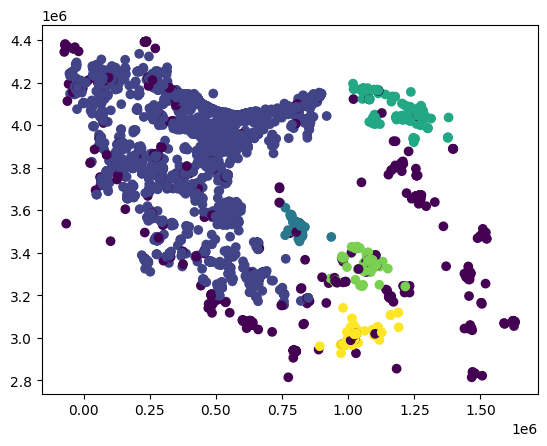

In [104]:
db111 = DBSCAN(eps=0.4, min_samples=100)
db111.fit(df_scaled)
labels = db111.labels_
n_noise = list(labels).count(-1)
print("noisee : ", n_noise)
plt.scatter(df_sample['utm_x'], df_sample['utm_y'], c=labels)
plt.show()

In [105]:
eps_values = [0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7, 0.8]
min_samples_values = [50, 70, 100, 150, 200, 300]
results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        
        db = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=-1
        )
        
        labels = db.fit_predict(df_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_percent = n_noise / len(labels) * 100
        
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_percent": noise_percent
        })

results_df = pd.DataFrame(results)

In [106]:
results_df

,eps,min_samples,n_clusters,n_noise,noise_percent
0,0.35,50,6,1252,6.260
1,0.35,70,7,1545,7.725
2,0.35,100,8,1958,9.790
3,0.35,150,6,2892,14.460
4,0.35,200,5,3601,18.005
5,0.35,300,7,4538,22.690
6,0.40,50,6,965,4.825
7,0.40,70,6,1210,6.050
8,0.40,100,5,1600,8.000
9,0.40,150,5,2142,10.710


In [107]:
results_df[results_df["n_clusters"] == 3]

,eps,min_samples,n_clusters,n_noise,noise_percent
19,0.50,70,3,751,3.755
22,0.50,200,3,1896,9.480
23,0.50,300,3,2460,12.300
24,0.55,50,3,417,2.085
28,0.55,200,3,1605,8.025
34,0.60,200,3,1431,7.155


noisee :  1605


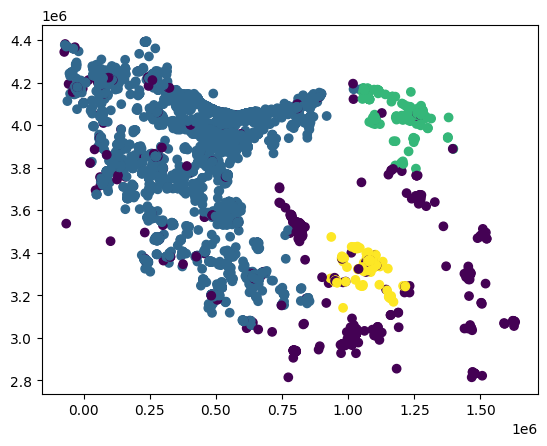

In [108]:
db111 = DBSCAN(eps=0.55, min_samples=200)
db111.fit(df_scaled)
labels = db111.labels_
n_noise = list(labels).count(-1)
print("noisee : ", n_noise)
plt.scatter(df_sample['utm_x'], df_sample['utm_y'], c=labels)
plt.show()

## now we try a sample of size 50000

In [45]:
df_sample = dff.sample(n=50000, random_state=42)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_sample)

In [46]:
eps_values = [0.4, 0.45, 0.5, 0.55, 0.6]
min_samples_values = [100, 150, 200, 250, 300, 400, 500]
results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        
        db = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=-1
        )
        
        labels = db.fit_predict(df_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_percent = n_noise / len(labels) * 100
        
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_percent": noise_percent
        })

results_df = pd.DataFrame(results)

In [114]:
results_df

,eps,min_samples,n_clusters,n_noise,noise_percent
0,0.40,100,5,1707,3.414
1,0.40,150,4,2456,4.912
2,0.40,200,5,3046,6.092
3,0.40,250,5,3676,7.352
4,0.40,300,5,4106,8.212
5,0.40,400,4,5792,11.584
6,0.40,500,4,6990,13.980
7,0.45,100,4,1305,2.610
8,0.45,150,3,1912,3.824
9,0.45,200,3,2362,4.724


In [131]:
df_plot = results_df[results_df['n_clusters'] == 3]
df_plot

,eps,min_samples,n_clusters,n_noise,noise_percent
8,0.45,150,3,1912,3.824
9,0.45,200,3,2362,4.724
14,0.50,100,3,1000,2.000
16,0.50,200,3,1841,3.682
20,0.50,500,3,4450,8.900
27,0.55,500,3,3821,7.642


C:\Users\IRANA COMPUTER\AppData\Local\Temp\ipykernel_3608\2309732366.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"clusters={df_plot.iloc[i][2]}, noise={df_plot.iloc[i][4]}%"
C:\Users\IRANA COMPUTER\AppData\Local\Temp\ipykernel_3608\2309732366.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"clusters={df_plot.iloc[i][2]}, noise={df_plot.iloc[i][4]}%"
C:\Users\IRANA COMPUTER\AppData\Local\Temp\ipykernel_3608\2309732366.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior).

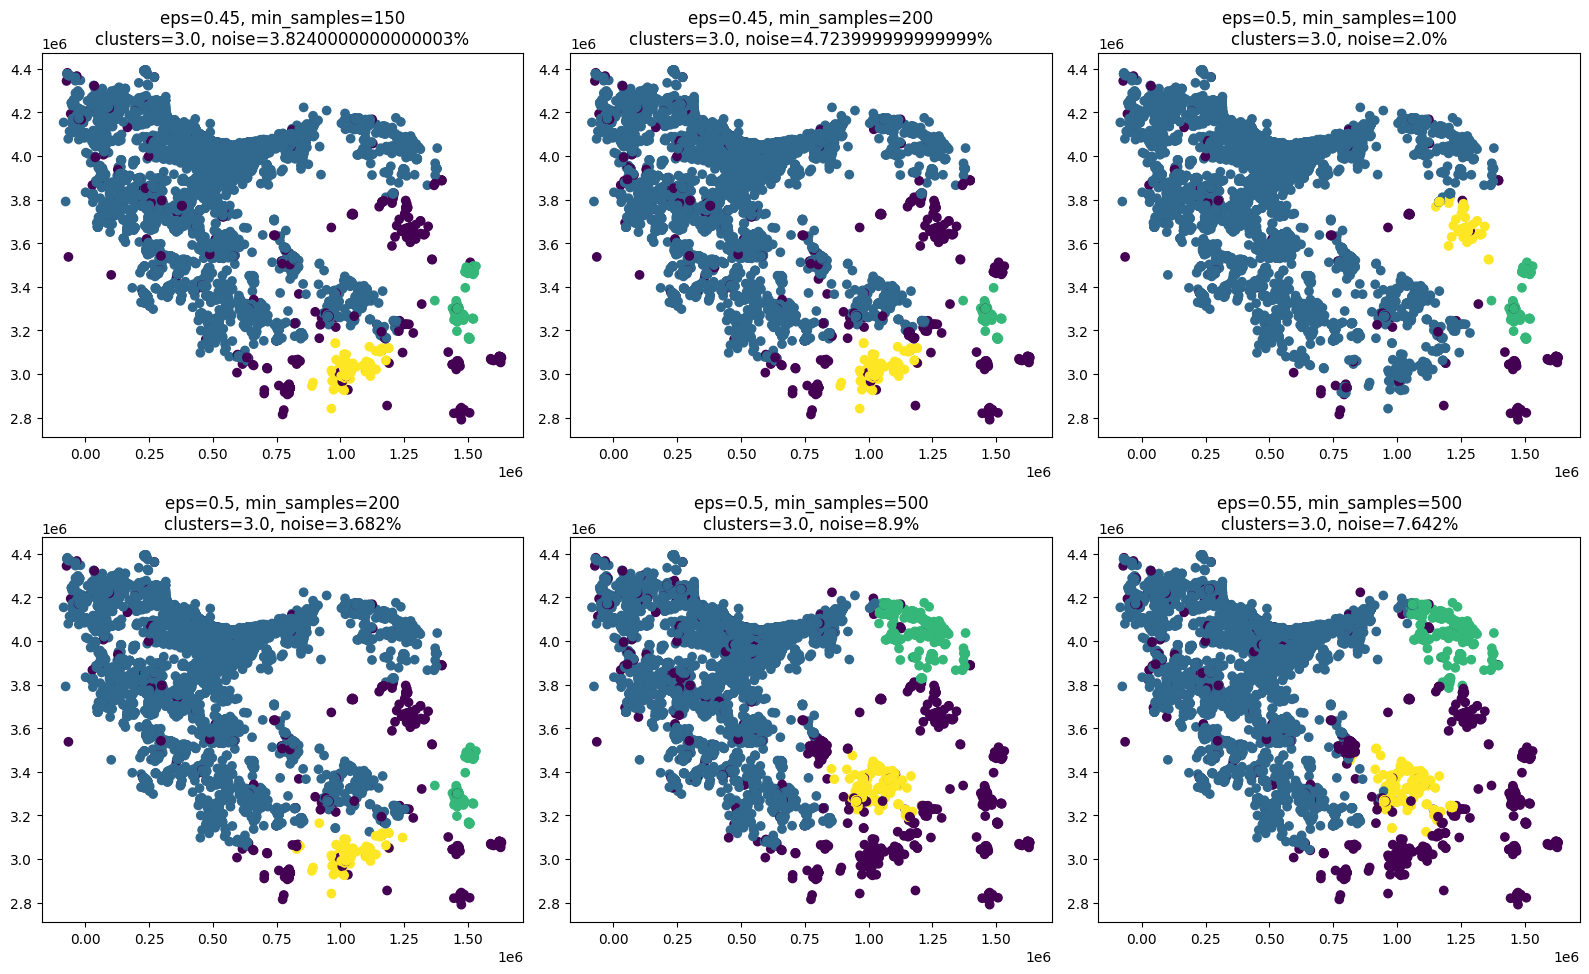

In [136]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i in range(6) :
    eps = float(df_plot.iloc[i]["eps"])
    min_samples = int(df_plot.iloc[i]["min_samples"])
    db = DBSCAN(eps=eps, min_samples=min_samples)
    db.fit(df_scaled)
    axes[i].scatter(df_sample['utm_x'], df_sample['utm_y'], c=db.labels_)
    axes[i].set_title(
        f"eps={eps}, min_samples={min_samples}\n"
        f"clusters={df_plot.iloc[i][2]}, noise={df_plot.iloc[i][4]}%"
    )

plt.tight_layout()
plt.show()

noise_percent :  8.078000000000001
2


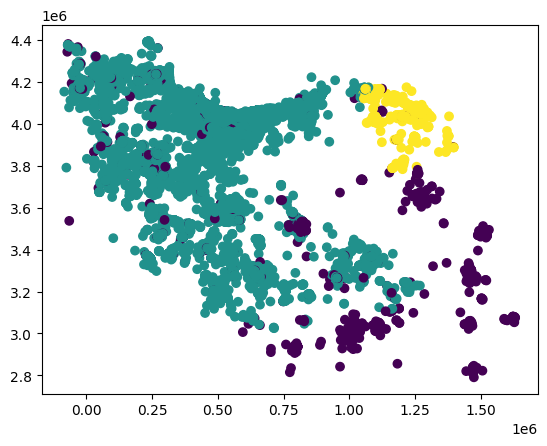

In [ ]:
db111 = DBSCAN(eps=0.57, min_samples=500)
db111.fit(df_scaled)
labels = db111.labels_
n_noise = list(labels).count(-1)
noise_percent = n_noise / len(labels) * 100
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("noise_percent : ", noise_percent)
print(n_clusters)
plt.scatter(df_sample['utm_x'], df_sample['utm_y'], c=labels)
plt.show()

## I could not run DBSCAN on the main dataframe because it was too large and caused a memory error. So, finally, I used a sample with a size of 100,000.


In [47]:
df_sample = dff.sample(n=100000, random_state=42)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_sample)

noise_percent :  5.729
3


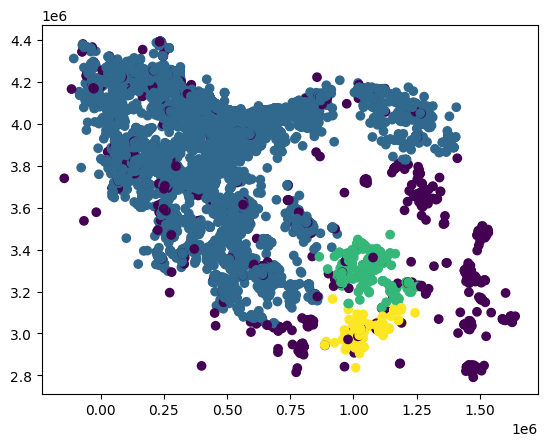

In [43]:
db111 = DBSCAN(eps=0.5, min_samples=700)
db111.fit(df_scaled)
labels = db111.labels_
n_noise = list(labels).count(-1)
noise_percent = n_noise / len(labels) * 100
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("noise_percent : ", noise_percent)
print(n_clusters)
plt.scatter(df_sample['utm_x'], df_sample['utm_y'], c=labels)
plt.show()

noise_percent :  4.272
3


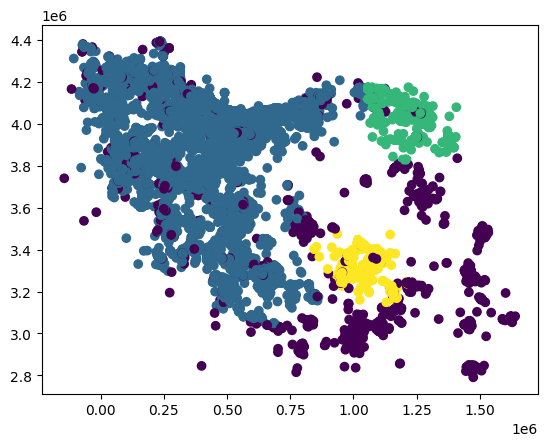

In [ ]:
db111 = DBSCAN(eps=0.5, min_samples=900)
db111.fit(df_scaled)
labels = db111.labels_
n_noise = list(labels).count(-1)
noise_percent = n_noise / len(labels) * 100
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("noise_percent : ", noise_percent)
print(n_clusters)
plt.scatter(df_sample['utm_x'], df_sample['utm_y'], c=labels)
plt.show()

noise_percent :  8.851
3


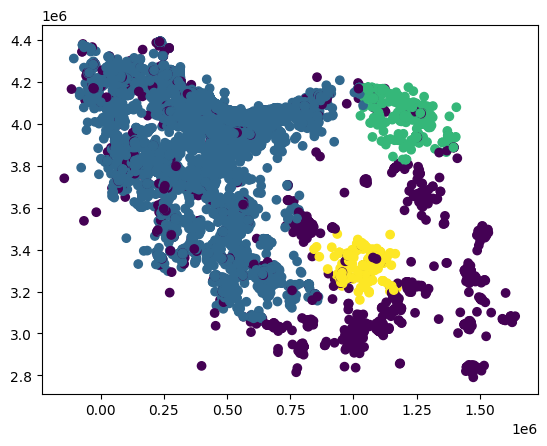

In [44]:
db111 = DBSCAN(eps=0.48, min_samples=900)
db111.fit(df_scaled)
labels = db111.labels_
n_noise = list(labels).count(-1)
noise_percent = n_noise / len(labels) * 100
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("noise_percent : ", noise_percent)
print(n_clusters)
plt.scatter(df_sample['utm_x'], df_sample['utm_y'], c=labels)
plt.show()

noise_percent :  7.8469999999999995
3


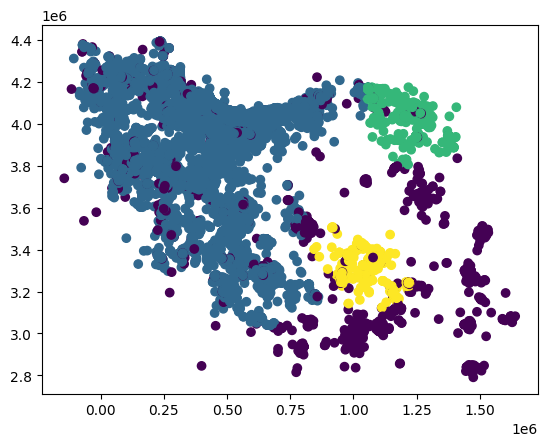

In [45]:
db111 = DBSCAN(eps=0.52, min_samples=900)
db111.fit(df_scaled)
labels = db111.labels_
n_noise = list(labels).count(-1)
noise_percent = n_noise / len(labels) * 100
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("noise_percent : ", noise_percent)
print(n_clusters)
plt.scatter(df_sample['utm_x'], df_sample['utm_y'], c=labels)
plt.show()

In [48]:
eps_values = [0.48, 0.5, 0.52, 0.53, 0.54, 0.55]
min_samples_values = [800, 900, 1100]
results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        
        db = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=-1
        )
        
        labels = db.fit_predict(df_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_percent = n_noise / len(labels) * 100
        
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_percent": noise_percent
        })

results_df = pd.DataFrame(results)

In [49]:
results_df

,eps,min_samples,n_clusters,n_noise,noise_percent
0,0.48,800,4,7532,7.532
1,0.48,900,3,8851,8.851
2,0.48,1100,3,9943,9.943
3,0.50,800,3,7164,7.164
4,0.50,900,3,8275,8.275
5,0.50,1100,3,9326,9.326
6,0.52,800,3,5880,5.880
7,0.52,900,3,7847,7.847
8,0.52,1100,3,8792,8.792
9,0.53,800,3,5712,5.712


In [50]:
results_df[results_df['n_clusters'] == 3]

,eps,min_samples,n_clusters,n_noise,noise_percent
1,0.48,900,3,8851,8.851
2,0.48,1100,3,9943,9.943
3,0.50,800,3,7164,7.164
4,0.50,900,3,8275,8.275
5,0.50,1100,3,9326,9.326
6,0.52,800,3,5880,5.880
7,0.52,900,3,7847,7.847
8,0.52,1100,3,8792,8.792
9,0.53,800,3,5712,5.712
10,0.53,900,3,7712,7.712


noise_percent :  7.385999999999999
2


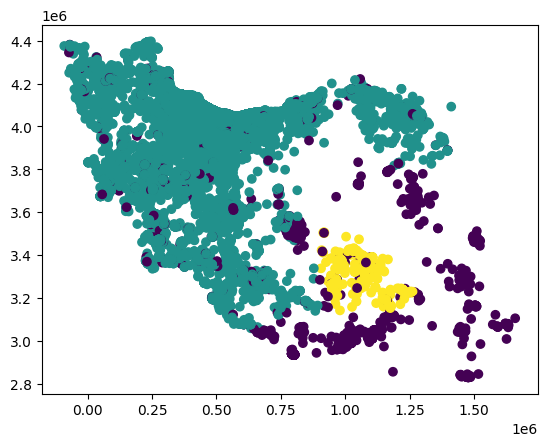

In [ ]:
db111 = DBSCAN(eps=0.52, min_samples=800)
db111.fit(df_scaled)
labels = db111.labels_
n_noise = list(labels).count(-1)
noise_percent = n_noise / len(labels) * 100
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("noise_percent : ", noise_percent)
print(n_clusters)
plt.scatter(df_sample['utm_x'], df_sample['utm_y'], c=labels)
plt.show()

noise_percent :  7.893999999999999
3


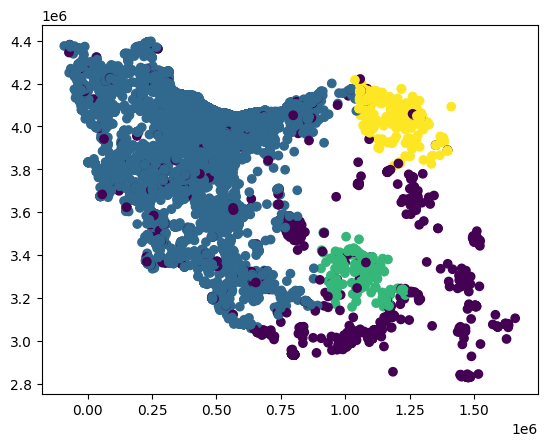

In [50]:
db111 = DBSCAN(eps=0.5, min_samples=800)
db111.fit(df_scaled)
labels = db111.labels_
n_noise = list(labels).count(-1)
noise_percent = n_noise / len(labels) * 100
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("noise_percent : ", noise_percent)
print(n_clusters)
plt.scatter(df_sample['utm_x'], df_sample['utm_y'], c=labels)
plt.show()

## I tested different combinations of hyperparameters, both manually and with a for loop. This was the best result I found.

noise_percent :  8.025
3


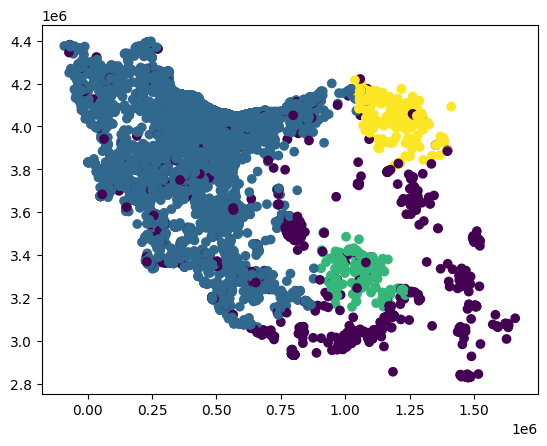

In [51]:
db111 = DBSCAN(eps=0.49, min_samples=800)
db111.fit(df_scaled)
labels = db111.labels_
n_noise = list(labels).count(-1)
noise_percent = n_noise / len(labels) * 100
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("noise_percent : ", noise_percent)
print(n_clusters)
plt.scatter(df_sample['utm_x'], df_sample['utm_y'], c=labels)
plt.show()

In DBSCAN, the hyperparameters have an important effect on the output.

The `eps` parameter controls the maximum distance between points in one neighborhood. If `eps` is small, the algorithm creates more noise points and may find more small clusters. If `eps` is large, more points are connected together, so the number of clusters usually becomes smaller.

The `min_samples` parameter controls the minimum number of points needed to form a dense area. If `min_samples` is small, the algorithm can create clusters more easily. If `min_samples` is large, the algorithm needs more dense points, so more points may become noise.

So, by changing `eps` and `min_samples`, the number of clusters and the amount of noise can change a lot.
